# Correct camera-vs-stage rotation

Every microscope's camera sensor sits at some small, fixed angle relative to
the stage's true X/Y travel axes. A FOV grid generated by
`acquisition.positions.create_grid_positions` assumes perfect alignment
between the two -- unrealistic in practice, and different microscopes carry
different amounts of this rotation. Left uncorrected, adjacent FOVs'
overlapping borders don't actually line up where the grid assumes they do,
which can lose or duplicate cells/barcodes at FOV borders during MERlin
segmentation/decoding.

**Method** (validated manually with BigStitcher before this notebook
automated it -- see `notes_BC341.pdf` and the `230818_BC341_adding_camera_
angle_correction_to_merlin` folder, both in
`BreastCancer/notebook/`): sample a handful of anchor FOVs (default 10),
register each one against its real 4-connected neighbours in their expected
overlapping border (phase cross-correlation on a DAPI/tissue-channel frame
from an already-imaged **cells round**), and fit ONE affine transform from
every anchor+neighbour correspondence pooled together
(`MERci.acquisition.camera_rotation`, using the `affine6p` package -- the
same one validated in the original BigStitcher-replacement work). Since the
rotation is a fixed optical-path property, this single global transform
corrects every FOV in the experiment, not just the sampled ones.

**Scope**: single-positions-file (legacy/single-tissue) layout only, matching
`measure_tissue_thickness_test.ipynb`/`stage_drift_dapi.ipynb`'s own
assumption -- the multi-boundary per-segment `positions_file` layout is not
handled here.

**Outputs**:
- `positions/camera_rotation_correction_{POSITIONS_TAG}.npy` -- the fitted
  3x3 affine matrix (`MERci.acquisition.camera_rotation.
  CameraRotationCorrection`, `affine6p` convention)
- `positions/camera_rotation_correction_{POSITIONS_TAG}.json` -- fit metadata
  (rotation/scale, correspondence count, source round)
- `positions/positions_{POSITIONS_TAG}_corrected.txt` -- the corrected FOV
  positions. **Use this file as MERlin's positions input instead of the raw
  grid** -- `07_create_merlin_scripts.ipynb` auto-detects it (falls back to
  the raw file if this notebook hasn't been run).

Section 13 additionally validates the fit on FOVs NOT used to compute it --
see that section's own intro for the rationale.


## 1 — Setup

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import KDTree

MERCI_DIR  = Path(os.getcwd()).parent.parent   # MERci/ (notebook lives in MERci/notebooks/misc/)
SAMPLE_DIR = MERCI_DIR.parent                  # experiment root
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import load_positions, save_positions_array, read_image_frames
from MERci.common.experiment_info import load_experiment_info, resolve_sample_identity, positions_file_tag
from MERci.acquisition.configs    import (
    find_frame_table_for_hal_config, get_camera_pixel_size_um, get_camera_frame_size,
)
from MERci.acquisition.positions  import find_grid_neighbor
from MERci.acquisition.camera_rotation import (
    NeighborCorrespondence, sample_neighbor_correspondences, fit_camera_rotation,
    filter_correspondence_outliers, apply_microscope_orientation, crop_overlap,
)
from MERci.acquisition.alignment import remove_hot_pixels
from MERci.scheduler        import resolve_round_flip_y
from MERci.analysis.round   import load_raw_frames_for_round, create_mosaic_ffc
from MERci.progress_display import ProgressReporter

NOTEBOOK_NAME = "correct_camera_rotation"

print(f"SAMPLE_DIR : {SAMPLE_DIR}")


SAMPLE_DIR : T:\Leonardo\BC553_sample_02\epi


## 2 — Parameters

In [2]:
SAMPLE_NAME, IMAGING_DIR = resolve_sample_identity(MERCI_DIR)
POSITIONS_TAG = positions_file_tag(SAMPLE_NAME, IMAGING_DIR)
IMAGE_SUFFIX = ".zarr"   # must match what HAL wrote

# Read from experiment_info.yaml (notebook 06) rather than hard-coding it --
# get_camera_pixel_size_um/get_camera_frame_size below are keyed on the EXACT
# microscope string, and a wrong guess here silently produces a wrong pixel
# size/frame geometry with no error (confirmed directly: a hard-coded wrong
# microscope in an earlier version of this notebook produced phase-
# correlation registrations that all failed silently -- error=1.0 on every
# correspondence -- because the assumed overlap-border crop no longer matched
# where the real images actually overlap).
info       = load_experiment_info(SAMPLE_DIR / "metadata" / "experiment_info.yaml")
MICROSCOPE = info.microscope

# Which already-imaged round to measure the rotation from -- by imaging_type
# (typically "cells": every FOV is imaged there, with a strong DAPI/tissue
# signal to register on), or set ROUND_ID directly to override.
ROUND_IMAGING_TYPE = "cells"
ROUND_ID            = None

# Path to a specific frame-table CSV, bypassing auto-resolution from the
# round's HAL config's <shutters> reference (find_frame_table_for_hal_config)
# -- set this when metadata/ has drifted out of sync with the real frame
# table used at acquisition time. None (default) auto-resolves as usual.
REFERENCE_FRAME_TABLE_PATH = None

# Registration colour (nm) and z (um) -- same convention as stage_drift_dapi.ipynb.
# No sensible default exists across experiments; this MUST be set explicitly to
# a z where REGISTRATION_COLOR_NM shows real tissue signal (e.g. from
# measure_tissue_thickness_test.ipynb's z_first_um/z_last_um for this round).
REGISTRATION_COLOR_NM = 405.0
REGISTRATION_Z_UM     = 12.0

# How many anchor FOVs to sample and register against their 4-connected
# neighbours (up to 4 correspondences each). The fit pools every anchor's
# correspondences into ONE affine (camera_rotation.fit_camera_rotation) --
# 10 anchors x up to 4 neighbours each is normally far more than the 3 points
# a 2-D affine strictly needs, giving the fit real redundancy against any one
# bad registration.
N_ANCHORS = 10

# Deterministic anchor sampling by default (reproducible re-runs); None for a
# fresh random sample every run.
SEED = 0

# Held-out validation (section 13): how many FRESH anchor FOVs -- disjoint
# from the ones used to fit the correction above -- to register and check
# the fit against. Symmetric default with N_ANCHORS; VALIDATION_SEED is a
# separate seed (not reused) purely so changing SEED alone never silently
# changes which FOVs get held out too.
N_VALIDATION_ANCHORS = 10
VALIDATION_SEED      = 1

# Image-orientation audit (section 4): how many anchors to trial per
# CANDIDATE (transpose, flip_horizontal, flip_vertical) combination. Small
# on purpose -- this only needs a clear signal, not a precise fit (that's
# what section 5/6 are for), and it pays for itself 8x over (once per
# candidate combination).
N_ORIENTATION_TRIAL_ANCHORS = 3

# Outlier rejection (sections 6 and 13): even with the right image
# orientation, individual registrations can still fail outright (weak
# signal, a bad phase-correlation peak) -- confirmed directly: real data
# clustered tightly at a few um with a handful of clear outliers an order of
# magnitude+ larger, a real gap, not a continuum. A correspondence is
# rejected if its shift exceeds median + MAD_THRESHOLD * robust_sigma
# (robust_sigma = 1.4826 * median absolute deviation -- the standard MAD-to-
# Gaussian-sigma conversion, 1/norm.ppf(0.75)). 5.0 is generous -- see
# camera_rotation.filter_correspondence_outliers's docstring.
MAD_THRESHOLD = 5.0

# Match tolerance for "is there a real FOV at this grid-neighbour position",
# as a fraction of step_size_um -- same default as acquisition.positions.
# find_exterior_fovs / find_grid_neighbor.
TOLERANCE_FRACTION = 0.25

# Sub-pixel registration precision (1/upsample_factor px); 10 -> 0.1 px, the
# same default acquisition.alignment.compute_fov_drifts uses.
UPSAMPLE_FACTOR = 10

# Zero the fitted affine's translation component -- see camera_rotation.
# fit_camera_rotation's docstring: every correspondence only measures a
# LOCAL, anchor-relative displacement, so a non-zero fitted translation
# reflects pooling noise across scattered anchors, not a real global origin
# shift.
ZERO_TRANSLATION = True

# Skip re-registering if a cached correspondences table already exists (see
# NOTEBOOK_GUIDELINES.md #3). Set True to force a fresh measurement (e.g.
# after changing N_ANCHORS/SEED/REGISTRATION_Z_UM).
FORCE_RECOMPUTE = False

# Half-width (um) of the zoomed corner-overlay crop (section 12) -- small
# enough to show pixel-scale misalignment, large enough to still contain
# real tissue signal. Widened from an earlier 15.0 now that section 10's FFC
# correction makes the tile's outer regions informative too, not just its
# bright centre. Tune per-experiment if the default crop looks empty/noisy.
CORNER_ZOOM_HALF_UM = 40.0

# Mosaic-comparison rendering (section 11) -- deliberately NOT cropping each
# FOV's overlap border (crop_px=0), unlike the production FFC mosaics in
# analysis/round.py: the whole point of this comparison is to SEE the
# overlap region, where camera rotation shows up as doubled/discontinuous
# tissue edges before correction. thumbnail_size only applies to the GLOBAL
# window view -- the 2x2 corner-block mosaic always uses native resolution
# (the camera's own real frame size), computed at runtime.
MOSAIC_THUMBNAIL_SIZE = (200, 200)
MOSAIC_CROP_PX         = 0

# Half-width (um) of the zoom crop into the 2x2 corner-block mosaic
# (section 11) -- tight enough to see individual nuclei at the seam, wide
# enough to still show real tissue structure either side of it.
MOSAIC_2X2_ZOOM_HALF_UM = 75.0

# Exterior FOVs sampled to estimate the flat-field-correction field
# (section 10) -- capped for a bounded one-time read cost regardless of how
# large/irregular the tissue's exterior perimeter is.
FFC_MAX_SAMPLES = 80

# The 9x9 mosaic (section 11) reads every included FOV's raw frame
# individually -- for a real multi-thousand-FOV round over a network drive,
# reading ALL of them (as a first version of this notebook did) took over 30
# minutes and never finished. Restrict it to a contiguous
# MOSAIC_9X9_N_FOVS x MOSAIC_9X9_N_FOVS block of FOVs, centred on section
# 10's chosen centre FOV, instead of the whole tissue -- still enough real
# 4-connected overlap borders to see whether the correction reduced the
# doubled/discontinuous seams, at a fraction of the read time.
MOSAIC_9X9_N_FOVS = 9

# Explicit plot font sizes (NOTEBOOK_GUIDELINES.md #5).
PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 10

print(f"Sample name   : {SAMPLE_NAME}")
print(f"Positions tag : {POSITIONS_TAG}")
print(f"Microscope    : {MICROSCOPE}")
print(f"N_ANCHORS     : {N_ANCHORS}")
print(f"N_VALIDATION_ANCHORS : {N_VALIDATION_ANCHORS}")


Sample name   : BC553_sample_02
Positions tag : BC553_sample_02_epi
Microscope    : MF3
N_ANCHORS     : 10
N_VALIDATION_ANCHORS : 10


## 3 — Resolve the reference round + registration frame

In [3]:
config = ExperimentConfig(
    data_dir       = SAMPLE_DIR / "data",
    metadata_dir   = SAMPLE_DIR / "metadata",
    analysis_dir   = SAMPLE_DIR / "analysis",
    settings_dir   = SAMPLE_DIR / "settings",
    round_info_csv = SAMPLE_DIR / "metadata" / "round_info.csv",
    positions_txt  = SAMPLE_DIR / "positions" / f"positions_{POSITIONS_TAG}.txt",
    image_suffix   = IMAGE_SUFFIX,
    microscope     = MICROSCOPE,
)
meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                image_suffix=config.image_suffix)

print("Available rounds (data folders):")
for rid in meta.valid_round_ids():
    series_list = meta.series_for_round(rid)
    types = sorted({(s.imaging_type or "?") for s in series_list})
    print(f"  round {rid:>2}  imaging_type={types}")


def resolve_round_id(meta, imaging_type):
    """First round_id whose series carry the given imaging_type."""
    for rid in meta.valid_round_ids():
        if any((s.imaging_type or "").strip().lower() == imaging_type.strip().lower()
               for s in meta.series_for_round(rid)):
            return rid
    raise ValueError(f"No round found with imaging_type={imaging_type!r}")


def load_round_frame_table(round_id, config, meta, frame_table_path=None):
    """(frame_table, hal_config_path, SeriesInfo) for round_id's first series with a
    hal_config. Mirrors stage_drift_dapi.ipynb's own helper of the same name."""
    for s in meta.series_for_round(round_id):
        if not s.hal_config:
            continue
        hal_path = Path(config.settings_dir) / s.hal_config
        if frame_table_path is not None:
            return pd.read_csv(frame_table_path, index_col=0), hal_path, s
        ft_path = find_frame_table_for_hal_config(hal_path, config.metadata_dir)
        if ft_path and ft_path.exists():
            return pd.read_csv(ft_path, index_col=0), hal_path, s
    raise FileNotFoundError(f"No frame table found for round {round_id}")


def nearest_frame_for_color_z(frame_table, color_nm, z_um):
    """Frame index of the given colour's frame with z closest to z_um."""
    candidates = frame_table[frame_table["color"].round(0) == round(color_nm)]
    if candidates.empty:
        raise ValueError(f"No frames of colour {color_nm:.0f} nm in this frame table.")
    return int((candidates["z"] - z_um).abs().idxmin())


target_round_id = ROUND_ID if ROUND_ID is not None else resolve_round_id(meta, ROUND_IMAGING_TYPE)
if not meta.round_fully_written(target_round_id):
    print(f"WARNING: round {target_round_id} is not yet fully written on disk -- "
          f"some FOVs sampled below may be missing.")

if REGISTRATION_Z_UM is None:
    raise ValueError(
        "REGISTRATION_Z_UM is not set (section 2) -- pick a z (um) where "
        f"REGISTRATION_COLOR_NM ({REGISTRATION_COLOR_NM:.0f} nm) actually shows real "
        "signal (e.g. from measure_tissue_thickness_test.ipynb's z_first_um/z_last_um) "
        "before continuing."
    )

frame_table, reference_hal_config_path, reference_series = load_round_frame_table(
    target_round_id, config, meta, frame_table_path=REFERENCE_FRAME_TABLE_PATH,
)
reference_frame_idx = nearest_frame_for_color_z(frame_table, REGISTRATION_COLOR_NM, REGISTRATION_Z_UM)
reference_frame_z   = float(frame_table.loc[reference_frame_idx, "z"])

PIXEL_SIZE_UM     = get_camera_pixel_size_um(MICROSCOPE)
FRAME_WIDTH_PX, _ = get_camera_frame_size(MICROSCOPE)
FRAME_WIDTH_UM    = FRAME_WIDTH_PX * PIXEL_SIZE_UM
FLIP_Y            = resolve_round_flip_y(target_round_id, config, meta)

full_positions = load_positions(config.positions_txt)   # {fov_id: (x, y)} -- nominal grid
fov_order = sorted(full_positions)

# STEP_SIZE_UM/OVERLAP_FRACTION are measured from the REAL positions file
# rather than trusted from ExperimentConfig's own step_size_um/
# non_overlap_fraction formula -- confirmed directly that trusting the
# formula (which depends on config.pixel_size_um/image_size_px/
# non_overlap_fraction matching this experiment's real camera/grid exactly)
# silently produced a wrong overlap-border crop when those didn't match,
# and every phase-correlation registration failed (error=1.0) as a result.
# The median nearest-neighbour distance across real FOV positions is the
# grid's true step size regardless of what generated it.
coords_arr       = np.array([full_positions[f] for f in fov_order])
nn_dist, _       = KDTree(coords_arr).query(coords_arr, k=2)
STEP_SIZE_UM     = float(np.median(nn_dist[:, 1]))
OVERLAP_FRACTION = max(0.0, 1.0 - STEP_SIZE_UM / FRAME_WIDTH_UM)

print(f"Target round      : {target_round_id}  (series pattern: {reference_series.name!r})")
print(f"Reference frame    : index {reference_frame_idx}, colour {REGISTRATION_COLOR_NM:.0f} nm, "
      f"z={reference_frame_z:.2f} um (requested z={REGISTRATION_Z_UM:.2f} um)")
print(f"Pixel size (um)    : {PIXEL_SIZE_UM}")
print(f"Frame width (um)   : {FRAME_WIDTH_UM:.3f}  ({FRAME_WIDTH_PX} px)")
print(f"Step size (um)     : {STEP_SIZE_UM:.3f}  (measured, median nearest-neighbour distance)")
print(f"Overlap fraction   : {OVERLAP_FRACTION:.3f}")
print(f"flip_y             : {FLIP_Y}")
print(f"FOVs in this round : {len(full_positions)}")


def load_dapi_frame(fov_id):
    path = reference_series.resolve_path(fov_id, config.image_suffix)
    return read_image_frames(path, [reference_frame_idx],
                              frame_width=config.frame_width, frame_height=config.frame_height)[0]


Available rounds (data folders):
  round  1  imaging_type=['cells']
  round  2  imaging_type=['bits']
  round  3  imaging_type=['bits']
  round  4  imaging_type=['bits']
  round  5  imaging_type=['bits']
  round  6  imaging_type=['bits']
  round  7  imaging_type=['bits']
  round  8  imaging_type=['bits']
  round  9  imaging_type=['bits']
  round 10  imaging_type=['bits']


Target round      : 1  (series pattern: 'hal-mf3-cells_{fov:04d}')
Reference frame    : index 12, colour 405 nm, z=12.00 um (requested z=12.00 um)
Pixel size (um)    : 0.108
Frame width (um)   : 221.184  (2048 px)
Step size (um)     : 199.066  (measured, median nearest-neighbour distance)
Overlap fraction   : 0.100
flip_y             : False
FOVs in this round : 1651


## 4 — Load this microscope's orientation convention from its MERlin microscope-parameters JSON

`crop_overlap` assumes a raw frame's row axis increases with stage +y and its
column axis with stage +x, with no flip -- but whether that's actually true
depends on the camera/mounting, and is NOT something to guess at: MERlin's
own microscope-parameters JSON (`data/configs/merlin/microscope/*.json`)
already records the verified `transpose`/`flip_horizontal`/`flip_vertical`
values for this exact microscope, so this notebook reads and applies THAT
directly, rather than treating orientation as unknown.

Confirmed directly on a real MF3 dataset why guessing -- even a
locally-reasonable one -- is not safe: an earlier version of this notebook
searched only 7 SINGLE transforms and picked "transpose" alone as the best
of them, which did reduce registered shifts from ~35 um down to ~3.4 um --
but `MERFISH3.json` also declares `flip_vertical=True`, a combination that
search never tried. The missing flip left a real, visible residual
mis-stitch in the mosaic. `detect_image_orientation` below now searches the
full 8-combination space (every `transpose`/`flip_horizontal`/
`flip_vertical` combination) purely as an AUDIT/cross-check against the
JSON's declared value -- not as the primary source of truth.


In [4]:
from MERci.acquisition.camera_rotation import detect_image_orientation
from MERci.acquisition.merlin_config import resolve_microscope_parameters_filename

microscope_params_path = (
    MERCI_DIR / "data" / "configs" / "merlin" / "microscope"
    / resolve_microscope_parameters_filename(MICROSCOPE)
)
microscope_params = json.loads(microscope_params_path.read_text())
ORIENT_TRANSPOSE       = bool(microscope_params.get("transpose", False))
ORIENT_FLIP_HORIZONTAL = bool(microscope_params.get("flip_horizontal", False))
ORIENT_FLIP_VERTICAL   = bool(microscope_params.get("flip_vertical", False))

print(f"Microscope parameters : {microscope_params_path}")
print(f"  transpose       = {ORIENT_TRANSPOSE}")
print(f"  flip_horizontal = {ORIENT_FLIP_HORIZONTAL}")
print(f"  flip_vertical   = {ORIENT_FLIP_VERTICAL}")

best_combination, orientation_scan_df = detect_image_orientation(
    fov_ids=fov_order,
    positions=full_positions,
    load_frame=load_dapi_frame,
    step_size_um=STEP_SIZE_UM,
    pixel_size_um=PIXEL_SIZE_UM,
    overlap_fraction=OVERLAP_FRACTION,
    n_trial_anchors=N_ORIENTATION_TRIAL_ANCHORS,
    tolerance_fraction=TOLERANCE_FRACTION,
    upsample_factor=UPSAMPLE_FACTOR,
    seed=SEED,
)
print("\nAudit -- all 8 (transpose, flip_horizontal, flip_vertical) combinations:")
print(orientation_scan_df.to_string(index=False))

config_mask = (
    (orientation_scan_df["transpose"] == ORIENT_TRANSPOSE)
    & (orientation_scan_df["flip_horizontal"] == ORIENT_FLIP_HORIZONTAL)
    & (orientation_scan_df["flip_vertical"] == ORIENT_FLIP_VERTICAL)
)
config_rank         = int(orientation_scan_df.index[config_mask][0])
config_median_shift = float(orientation_scan_df.loc[config_mask, "median_shift_um"].iloc[0])
print(f"\nMicroscope-parameters combination ranks #{config_rank + 1}/8 by median shift "
      f"({config_median_shift:.2f} um).")

if best_combination != (ORIENT_TRANSPOSE, ORIENT_FLIP_HORIZONTAL, ORIENT_FLIP_VERTICAL):
    print(f"WARNING: the empirically best combination {best_combination} differs from "
          f"the microscope-parameters JSON's declared "
          f"({ORIENT_TRANSPOSE}, {ORIENT_FLIP_HORIZONTAL}, {ORIENT_FLIP_VERTICAL}). "
          "Using the JSON's value regardless below -- it's MERlin's own verified "
          "convention -- but investigate this disagreement before trusting the fit.")
else:
    print("Matches the empirically best combination -- consistent.")


Microscope parameters : T:\Leonardo\BC553_sample_02\epi\MERci\data\configs\merlin\microscope\MERFISH3.json
  transpose       = True
  flip_horizontal = False
  flip_vertical   = True



Audit -- all 8 (transpose, flip_horizontal, flip_vertical) combinations:
 transpose  flip_horizontal  flip_vertical  n_correspondences  median_shift_um
      True            False           True                 12         3.427765
      True             True           True                 12         6.259436
      True            False          False                 12         6.359084
      True             True          False                 12        31.719602
     False             True           True                 12        32.016803
     False            False           True                 12        35.024400
     False             True          False                 12        47.790001
     False            False          False                 12        60.798605

Microscope-parameters combination ranks #1/8 by median shift (3.43 um).
Matches the empirically best combination -- consistent.


## 5 — Sample neighbour correspondences (calculation, cached)

Registers `N_ANCHORS` randomly-sampled FOVs against their real 4-connected
neighbours in the DAPI/tissue channel (phase cross-correlation on the
overlapping border crop). Cached to
`analysis/cache/correct_camera_rotation/neighbor_correspondences.csv` so
re-running the notebook doesn't re-register unless `FORCE_RECOMPUTE=True`.


In [5]:
CACHE_DIR = config.analysis_dir / "cache" / NOTEBOOK_NAME
CACHE_DIR.mkdir(parents=True, exist_ok=True)
correspondences_csv = CACHE_DIR / "neighbor_correspondences.csv"

if correspondences_csv.exists() and not FORCE_RECOMPUTE:
    correspondences_df = pd.read_csv(correspondences_csv)
    print(f"Loaded cached correspondences: {correspondences_csv}  ({len(correspondences_df)} rows)")
else:
    n_anchors_actual = min(N_ANCHORS, len(fov_order))
    reporter = ProgressReporter(total=n_anchors_actual * 4, label="Registering neighbour pairs")

    def _progress(done, total):
        reporter.update(done - reporter.n_done)

    correspondences = sample_neighbor_correspondences(
        fov_ids=fov_order,
        positions=full_positions,
        load_frame=load_dapi_frame,
        step_size_um=STEP_SIZE_UM,
        pixel_size_um=PIXEL_SIZE_UM,
        overlap_fraction=OVERLAP_FRACTION,
        n_anchors=N_ANCHORS,
        tolerance_fraction=TOLERANCE_FRACTION,
        upsample_factor=UPSAMPLE_FACTOR,
        orient_transpose=ORIENT_TRANSPOSE,
        orient_flip_horizontal=ORIENT_FLIP_HORIZONTAL,
        orient_flip_vertical=ORIENT_FLIP_VERTICAL,
        seed=SEED,
        progress_callback=_progress,
    )
    reporter.done()

    correspondences_df = pd.DataFrame([{
        "anchor_fov": c.anchor_fov, "neighbor_fov": c.neighbor_fov, "direction": c.direction,
        "nominal_x": c.nominal_xy[0], "nominal_y": c.nominal_xy[1],
        "measured_x": c.measured_xy[0], "measured_y": c.measured_xy[1],
        "error": c.error,
    } for c in correspondences])
    correspondences_df.to_csv(correspondences_csv, index=False)
    print(f"Sampled {len(correspondences_df)} neighbour correspondence(s) from "
          f"{n_anchors_actual} anchor FOV(s). Saved: {correspondences_csv}")

print(correspondences_df.head())


Loaded cached correspondences: T:\Leonardo\BC553_sample_02\epi\analysis\cache\correct_camera_rotation\neighbor_correspondences.csv  (37 rows)
   anchor_fov  neighbor_fov direction  nominal_x  nominal_y  measured_x  \
0        1176          1193     right  6689.0152  -961.6176   6689.0368   
1        1176          1131      left  6290.8840  -961.6176   6290.8840   
2        1176          1177        up  6489.9496  -762.5520   6493.2976   
3        1176          1175      down  6489.9496 -1160.6832   6486.8068   
4         640           697     right  4101.1624  -563.4864   4101.1624   

   measured_y  error  
0   -964.0800    1.0  
1   -958.1616    1.0  
2   -761.1480    1.0  
3  -1161.9792    1.0  
4   -568.3248    1.0  


## 6 — Fit the camera-rotation affine transform

In [6]:
correspondences_all = [
    NeighborCorrespondence(
        anchor_fov=int(r.anchor_fov), neighbor_fov=int(r.neighbor_fov), direction=r.direction,
        nominal_xy=(r.nominal_x, r.nominal_y), measured_xy=(r.measured_x, r.measured_y), error=r.error,
    )
    for r in correspondences_df.itertuples()
]
correspondences, rejected = filter_correspondence_outliers(correspondences_all, mad_threshold=MAD_THRESHOLD)
print(f"Kept {len(correspondences)}/{len(correspondences_all)} correspondence(s) for the fit "
      f"({len(rejected)} rejected as outliers -- individual failed registrations, "
      f"the same 'bad link' problem BigStitcher's manual workflow curated by hand).")
for c in rejected:
    shift_um = float(np.hypot(c.measured_xy[0] - c.nominal_xy[0], c.measured_xy[1] - c.nominal_xy[1]))
    print(f"  rejected: anchor={c.anchor_fov} neighbor={c.neighbor_fov} "
          f"direction={c.direction!r} shift={shift_um:.2f} um")

correction = fit_camera_rotation(correspondences, zero_translation=ZERO_TRANSLATION)

M = correction.matrix
rotation_deg = float(np.degrees(np.arctan2(M[1, 0], M[0, 0])))
scale        = float(np.sqrt(M[0, 0] ** 2 + M[1, 0] ** 2))
print(f"Fitted from {correction.n_correspondences} correspondence(s):")
print(f"  rotation : {rotation_deg:.4f} deg")
print(f"  scale    : {scale:.6f}")
print(f"  matrix   :\n{M}")

positions_dir = SAMPLE_DIR / "positions"
matrix_path = positions_dir / f"camera_rotation_correction_{POSITIONS_TAG}.npy"
correction.save(matrix_path)

meta_path = positions_dir / f"camera_rotation_correction_{POSITIONS_TAG}.json"
with meta_path.open("w") as fh:
    json.dump({
        "n_correspondences": correction.n_correspondences,
        "zero_translation": correction.zero_translation,
        "rotation_deg": rotation_deg,
        "scale": scale,
        "source_round_id": target_round_id,
        "registration_color_nm": REGISTRATION_COLOR_NM,
        "registration_z_um": REGISTRATION_Z_UM,
    }, fh, indent=2)

print(f"Saved correction matrix  : {matrix_path}")
print(f"Saved correction metadata: {meta_path}")


Kept 32/37 correspondence(s) for the fit (5 rejected as outliers -- individual failed registrations, the same 'bad link' problem BigStitcher's manual workflow curated by hand).
  rejected: anchor=131 neighbor=111 direction='left' shift=11.23 um
  rejected: anchor=713 neighbor=800 direction='right' shift=56.62 um
  rejected: anchor=1372 neighbor=1409 direction='right' shift=21.77 um
  rejected: anchor=1372 neighbor=1371 direction='left' shift=87.84 um
  rejected: anchor=1372 neighbor=1373 direction='up' shift=53.16 um
Fitted from 32 correspondence(s):
  rotation : 0.0095 deg
  scale    : 0.999838
  matrix   :
[[9.99837684e-01 4.17068797e-05 0.00000000e+00]
 [1.65874230e-04 1.00010636e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Saved correction matrix  : T:\Leonardo\BC553_sample_02\epi\positions\camera_rotation_correction_BC553_sample_02_epi.npy
Saved correction metadata: T:\Leonardo\BC553_sample_02\epi\positions\camera_rotation_correction_BC553_sample_02_epi.jso

## 7 — Apply the correction to the full positions file

In [7]:
nominal_coords   = np.array([full_positions[f] for f in fov_order], dtype=float)
corrected_coords = correction.transform_points(nominal_coords)
corrected_positions = {f: tuple(corrected_coords[i]) for i, f in enumerate(fov_order)}

corrected_path = positions_dir / f"positions_{POSITIONS_TAG}_corrected.txt"
save_positions_array(corrected_coords, corrected_path)

print(f"Applied camera-rotation correction to all {len(full_positions)} FOV(s).")
print(f"Wrote corrected positions file: {corrected_path}")
print("Use this file as MERlin's positions input instead of the raw grid "
      "(07_create_merlin_scripts.ipynb auto-detects it).")

figures_dir = config.analysis_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)


Applied camera-rotation correction to all 1651 FOV(s).
Wrote corrected positions file: T:\Leonardo\BC553_sample_02\epi\positions\positions_BC553_sample_02_epi_corrected.txt
Use this file as MERlin's positions input instead of the raw grid (07_create_merlin_scripts.ipynb auto-detects it).


## 8 — Plot: original vs. corrected positions overlay

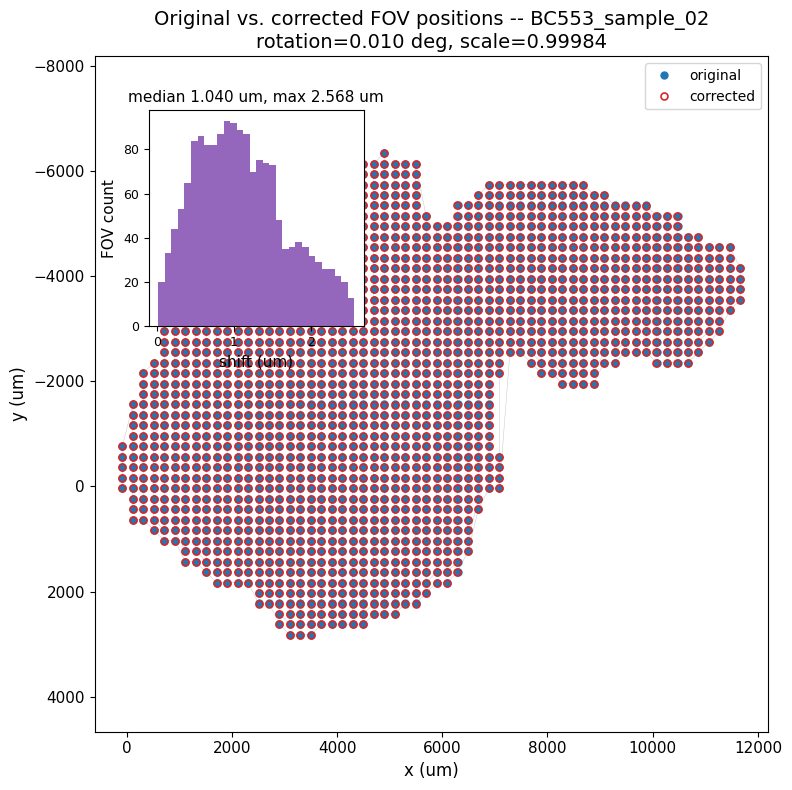

Saved: T:\Leonardo\BC553_sample_02\epi\analysis\figures\correct_camera_rotation.positions_overlay.png


In [8]:
shift_um = np.linalg.norm(corrected_coords - nominal_coords, axis=1)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(nominal_coords[:, 0], nominal_coords[:, 1], "-", lw=0.3, color="0.75", zorder=1)
ax.plot(nominal_coords[:, 0], nominal_coords[:, 1], "o", ms=5, color="tab:blue",
        label="original", zorder=2)
ax.plot(corrected_coords[:, 0], corrected_coords[:, 1], "o", ms=5, mfc="none",
        mec="tab:red", mew=1.2, label="corrected", zorder=3)
ax.invert_yaxis()
ax.axis("equal")
ax.set_xlabel("x (um)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("y (um)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Original vs. corrected FOV positions -- {SAMPLE_NAME}\n"
             f"rotation={rotation_deg:.3f} deg, scale={scale:.5f}", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE, loc="upper right")

# Inset: distribution of the per-FOV shift distance (original -> corrected)
# over ALL FOVs, not just the sampled correspondences -- shows the fitted
# transform's real cumulative effect at every FOV even when it's too subtle
# to see by eye in the overlay above (a small rotation/scale still adds up
# over long distances from the affine's effective centre).
inset = ax.inset_axes([0.08, 0.60, 0.32, 0.32])
inset.hist(shift_um, bins=30, color="tab:purple")
inset.set_xlabel("shift (um)", fontsize=PLOT_TICK_FONTSIZE)
inset.set_ylabel("FOV count", fontsize=PLOT_TICK_FONTSIZE)
inset.tick_params(labelsize=max(PLOT_TICK_FONTSIZE - 2, 6))
inset.set_title(f"median {np.median(shift_um):.3f} um, max {shift_um.max():.3f} um",
                 fontsize=PLOT_TICK_FONTSIZE)

fig.tight_layout()
fig_path = figures_dir / f"{NOTEBOOK_NAME}.positions_overlay.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")


## 9 — Plot: original & corrected positions with FOV grids

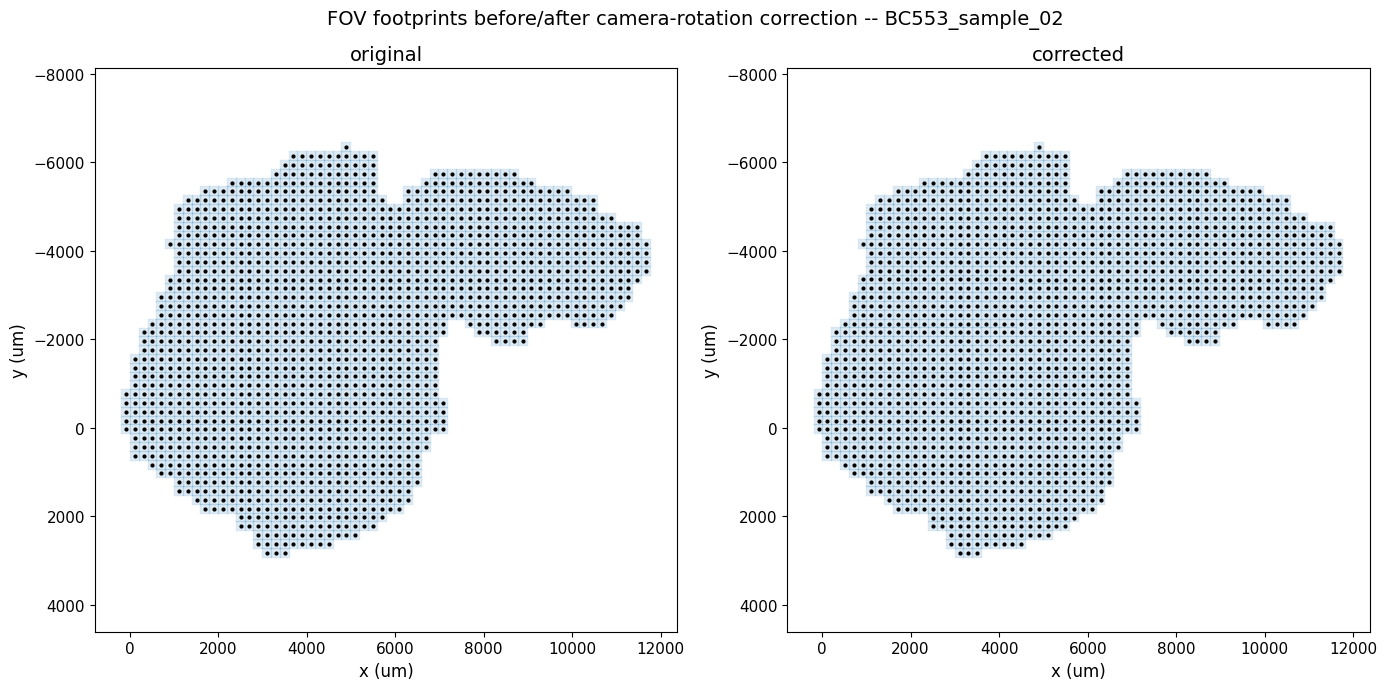

Saved: T:\Leonardo\BC553_sample_02\epi\analysis\figures\correct_camera_rotation.fov_grids.png


In [9]:
fov_size_um = FRAME_WIDTH_UM
half = fov_size_um / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, coords, title in ((axes[0], nominal_coords, "original"), (axes[1], corrected_coords, "corrected")):
    for x, y in coords:
        ax.add_patch(mpatches.Rectangle((x - half, y - half), fov_size_um, fov_size_um,
                                         lw=0.3, edgecolor="tab:blue", facecolor="tab:blue", alpha=0.15))
    ax.plot(coords[:, 0], coords[:, 1], "o", ms=2, color="k")
    ax.invert_yaxis()
    ax.axis("equal")
    ax.set_title(title, fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlabel("x (um)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel("y (um)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)

fig.suptitle(f"FOV footprints before/after camera-rotation correction -- {SAMPLE_NAME}",
             fontsize=PLOT_TITLE_FONTSIZE)
fig.tight_layout()
fig_path = figures_dir / f"{NOTEBOOK_NAME}.fov_grids.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")


## 10 — Prepare the 3x3 mosaic/overlay diagnostics: pick a centre FOV, compute a flat-field-correction field

Sections 11-12 both need (a) one real, complete 3x3 (8-connected) FOV
neighbourhood -- a centre FOV plus all 8 of its neighbours -- and (b) a
flat-field-correction (FFC) field for `REGISTRATION_COLOR_NM` -- computed
once here and reused by both, so the two diagnostics are directly
comparable.

Without FFC, each FOV's own vignetting (illumination falloff toward the
edges/corners -- see `analysis/ffc.py`) makes every tile's BORDER dark
regardless of alignment, which is exactly the region a seam/overlap
diagnostic most needs to see clearly. FFC is estimated from a sample of
grid-EXTERIOR FOVs (the same convention the production round-mosaic pipeline
uses, `MERci.analysis.ffc`), capped at `FFC_MAX_SAMPLES` for a bounded
one-time cost, and cached like every other calculation in this notebook.


In [10]:
def find_3x3_block(fov_ids, positions, step_size_um, tolerance_fraction):
    """First complete 3x3 (8-connected) FOV neighbourhood found among
    fov_ids -- a centre FOV plus all 8 of its neighbours (4-connected +
    diagonal). Returns a dict keyed by compass direction (plus "center"),
    or None if no candidate has a complete neighbourhood."""
    def _diag(fov_a, dir_from_a, fov_b, dir_from_b):
        d = find_grid_neighbor(fov_a, positions, dir_from_a, step_size_um, tolerance_fraction)
        if d is None:
            d = find_grid_neighbor(fov_b, positions, dir_from_b, step_size_um, tolerance_fraction)
        return d

    for center in fov_ids:
        up    = find_grid_neighbor(center, positions, "up",    step_size_um, tolerance_fraction)
        down  = find_grid_neighbor(center, positions, "down",  step_size_um, tolerance_fraction)
        left  = find_grid_neighbor(center, positions, "left",  step_size_um, tolerance_fraction)
        right = find_grid_neighbor(center, positions, "right", step_size_um, tolerance_fraction)
        if None in (up, down, left, right):
            continue
        up_left    = _diag(up, "left", left, "up")
        up_right   = _diag(up, "right", right, "up")
        down_left  = _diag(down, "left", left, "down")
        down_right = _diag(down, "right", right, "down")
        if None in (up_left, up_right, down_left, down_right):
            continue
        return {
            "center": center, "up": up, "down": down, "left": left, "right": right,
            "up_left": up_left, "up_right": up_right,
            "down_left": down_left, "down_right": down_right,
        }
    return None


# Search among FOVs already confirmed to have usable signal -- the anchors/
# neighbours of the KEPT (non-outlier) training correspondences -- rather
# than fov_order's raster scan order. Confirmed directly: the first raster-
# order block happened to sit at a real tissue edge with almost no signal at
# REGISTRATION_Z_UM, and FFC (below) can't flatten a field that's dividing
# near-zero signal -- it just re-introduces the field's own shape as a
# smooth gradient. A FOV that already registered well is real evidence it
# has real signal to show.
vetted_fov_ids = sorted({c.anchor_fov for c in correspondences} | {c.neighbor_fov for c in correspondences})
block_3x3 = find_3x3_block(vetted_fov_ids, full_positions, STEP_SIZE_UM, TOLERANCE_FRACTION)
if block_3x3 is None:
    print("No complete 3x3 block found among vetted (well-registered) FOVs -- falling back to the full grid.")
    block_3x3 = find_3x3_block(fov_order, full_positions, STEP_SIZE_UM, TOLERANCE_FRACTION)
if block_3x3 is None:
    raise RuntimeError("No complete 3x3 (8-connected) FOV neighbourhood found -- "
                        "try a larger TOLERANCE_FRACTION.")
anchor_fov = block_3x3["center"]
print(f"3x3 block centred on FOV {anchor_fov}: {block_3x3}")

# The FIT (sections 5/6/13) applies ORIENT_* internally inside
# sample_neighbor_correspondences/register_neighbor_pair -- load_dapi_frame itself
# must stay raw for that path. This mosaic-VISUALIZATION path calls load_dapi_frame
# directly though, so it must apply the same orientation itself -- confirmed directly
# this was missing: every mosaic diagnostic below was silently built from raw,
# uncorrected frames, regardless of ORIENT_TRANSPOSE/FLIP_HORIZONTAL/FLIP_VERTICAL.
block_3x3_frames = {
    name: apply_microscope_orientation(load_dapi_frame(fov_id), ORIENT_TRANSPOSE,
                                        ORIENT_FLIP_HORIZONTAL, ORIENT_FLIP_VERTICAL)
    for name, fov_id in block_3x3.items()
}

# Section 12's colour overlay only needs one corner (NE: centre/right/up/
# up_right) -- kept under its original anchor/right/up/diag names.
block_names   = {"anchor": block_3x3["center"], "right": block_3x3["right"],
                  "up": block_3x3["up"], "diag": block_3x3["up_right"]}
block_fov_ids = list(block_names.values())
block_frames  = {"anchor": block_3x3_frames["center"], "right": block_3x3_frames["right"],
                  "up": block_3x3_frames["up"], "diag": block_3x3_frames["up_right"]}
print(f"Corner (NE) sub-block for section 12: {block_names}")


3x3 block centred on FOV 130: {'center': 130, 'up': 131, 'down': 129, 'left': 112, 'right': 178, 'up_left': 111, 'up_right': 177, 'down_left': 113, 'down_right': 179}


Corner (NE) sub-block for section 12: {'anchor': 130, 'right': 178, 'up': 131, 'diag': 177}


In [11]:
from MERci.acquisition.positions import find_exterior_fovs
from MERci.analysis.ffc import compute_ffc_field_for_color, save_ffc_field, load_ffc_field

ffc_cache_path = CACHE_DIR / f"ffc_field_{REGISTRATION_COLOR_NM:.0f}nm.npz"

if ffc_cache_path.exists() and not FORCE_RECOMPUTE:
    ffc_field, ffc_meta = load_ffc_field(ffc_cache_path)
    print(f"Loaded cached FFC field: {ffc_cache_path}  (from {int(ffc_meta.get('n_samples'))} sample(s))")
else:
    exterior_fovs = sorted(find_exterior_fovs(full_positions, STEP_SIZE_UM, tolerance_fraction=TOLERANCE_FRACTION))
    if len(exterior_fovs) > FFC_MAX_SAMPLES:
        rng = np.random.default_rng(SEED)
        exterior_fovs = [int(f) for f in rng.choice(exterior_fovs, size=FFC_MAX_SAMPLES, replace=False)]
    ffc_samples = [
        (reference_series.resolve_path(fov_id, config.image_suffix), reference_frame_idx)
        for fov_id in exterior_fovs
    ]
    print(f"Computing FFC field from {len(ffc_samples)} exterior FOV(s) "
          f"(one frame read each -- may take a minute)...")
    ffc_field, ffc_meta = compute_ffc_field_for_color(
        ffc_samples, frame_width=config.frame_width, frame_height=config.frame_height,
    )
    save_ffc_field(ffc_cache_path, ffc_field, ffc_meta)
    print(f"Saved: {ffc_cache_path}")

# The field is computed/cached in RAW sensor pixel space (same as every other
# raw frame read in this notebook) -- orient it here, once, so dividing an
# already-oriented frame by it (create_mosaic_ffc below) lines up correctly.
# Equivalent to orienting every sample frame before averaging: transpose/flip is a
# fixed per-pixel relabelling, so it commutes with the per-pixel average that built
# this field.
ffc_field = apply_microscope_orientation(ffc_field, ORIENT_TRANSPOSE,
                                          ORIENT_FLIP_HORIZONTAL, ORIENT_FLIP_VERTICAL)
print(f"FFC field: shape={ffc_field.shape}, min={ffc_field.min():.3f}, max={ffc_field.max():.3f}")


Loaded cached FFC field: T:\Leonardo\BC553_sample_02\epi\analysis\cache\correct_camera_rotation\ffc_field_405nm.npz  (from 80 sample(s))
FFC field: shape=(2048, 2048), min=0.257, max=1.000


## 11 — Plot: original vs. corrected DAPI mosaic comparison

Three increasingly zoomed-in views, original vs. corrected side by side, all
flat-field-corrected (section 10) and placed with NO padding gap between
tiles (so any doubled/discontinuous tissue edge at a seam is the
camera-rotation effect itself, not an artefact of a black gap):

1. **9x9 FOVs**, centred on section 10's chosen centre FOV -- a sense of the
   alignment across a real neighbourhood (reading every FOV in a real
   multi-thousand-FOV round over a network drive is a 30+ minute read for a
   single diagnostic plot, hence the window instead of the whole tissue).
2. **3x3 FOVs** (the centre FOV + all 8 of its neighbours, section 10), at
   NATIVE resolution (no downsampling) -- the 9x9 view above is too coarse
   to judge adjacent-FOV alignment at.
3. **The 4 corners of the centre FOV** -- a `MOSAIC_2X2_ZOOM_HALF_UM`-wide
   crop at each of the four points inside the SAME 3x3 mosaic where the
   centre FOV meets two 4-connected neighbours and one diagonal neighbour
   (NW/NE/SW/SE).


In [12]:
center_xy      = full_positions[anchor_fov]
half_window_um = MOSAIC_9X9_N_FOVS * STEP_SIZE_UM / 2
window_fov_ids = [
    f for f, (x, y) in full_positions.items()
    if abs(x - center_xy[0]) <= half_window_um and abs(y - center_xy[1]) <= half_window_um
]
print(f"9x9 window: {len(window_fov_ids)} FOV(s) around FOV {anchor_fov} "
      f"({center_xy[0]:.1f}, {center_xy[1]:.1f}) um "
      f"(+/-{half_window_um:.1f} um -- MOSAIC_9X9_N_FOVS={MOSAIC_9X9_N_FOVS}).")

window_raw_frames, _ = load_raw_frames_for_round(
    target_round_id, meta, reference_frame_idx, fov_subset=window_fov_ids,
    frame_width=config.frame_width, frame_height=config.frame_height,
)
# Same missing-orientation bug as block_3x3_frames above -- load_raw_frames_for_round
# is a plain raw reader (shared with production round mosaics that have no camera-
# rotation concept at all), so this diagnostic must apply ORIENT_* itself too.
window_raw_frames = {
    fov_id: apply_microscope_orientation(frame, ORIENT_TRANSPOSE,
                                          ORIENT_FLIP_HORIZONTAL, ORIENT_FLIP_VERTICAL)
    for fov_id, frame in window_raw_frames.items()
}
print(f"Loaded {len(window_raw_frames)} raw DAPI frame(s) for the 9x9 window.")


9x9 window: 63 FOV(s) around FOV 130 (1314.2, -3350.4) um (+/-895.8 um -- MOSAIC_9X9_N_FOVS=9).


Loaded 63 raw DAPI frame(s) for the 9x9 window.


In [13]:
window_original_positions  = {f: full_positions[f] for f in window_raw_frames}
window_corrected_positions = {f: corrected_positions[f] for f in window_raw_frames}

window_original_canvas = create_mosaic_ffc(
    window_raw_frames, window_original_positions,
    CACHE_DIR / f"mosaic_round{target_round_id}_9x9_original.png",
    ffc_field=ffc_field, crop_px=MOSAIC_CROP_PX, padding=0,
    thumbnail_size=MOSAIC_THUMBNAIL_SIZE, flip_y=FLIP_Y,
)
window_corrected_canvas = create_mosaic_ffc(
    window_raw_frames, window_corrected_positions,
    CACHE_DIR / f"mosaic_round{target_round_id}_9x9_corrected.png",
    ffc_field=ffc_field, crop_px=MOSAIC_CROP_PX, padding=0,
    thumbnail_size=MOSAIC_THUMBNAIL_SIZE, flip_y=FLIP_Y,
)

# 3x3 block, NATIVE resolution -- create_mosaic_ffc only resizes a tile when
# it doesn't already match thumbnail_size, so passing the camera's own real
# frame size here skips downsampling entirely.
block3x3_raw_frames_by_fov = {fov_id: block_3x3_frames[name] for name, fov_id in block_3x3.items()}
block3x3_original_by_fov   = {fov_id: full_positions[fov_id] for fov_id in block_3x3.values()}
block3x3_corrected_by_fov  = {fov_id: corrected_positions[fov_id] for fov_id in block_3x3.values()}

block3x3_original_canvas = create_mosaic_ffc(
    block3x3_raw_frames_by_fov, block3x3_original_by_fov,
    CACHE_DIR / f"mosaic_round{target_round_id}_3x3_original.png",
    ffc_field=ffc_field, crop_px=0, padding=0,
    thumbnail_size=(FRAME_WIDTH_PX, FRAME_WIDTH_PX), flip_y=FLIP_Y,
)
block3x3_corrected_canvas = create_mosaic_ffc(
    block3x3_raw_frames_by_fov, block3x3_corrected_by_fov,
    CACHE_DIR / f"mosaic_round{target_round_id}_3x3_corrected.png",
    ffc_field=ffc_field, crop_px=0, padding=0,
    thumbnail_size=(FRAME_WIDTH_PX, FRAME_WIDTH_PX), flip_y=FLIP_Y,
)
print(f"3x3 mosaic canvases: original={block3x3_original_canvas.shape}, "
      f"corrected={block3x3_corrected_canvas.shape}")


3x3 mosaic canvases: original=(6143, 6143), corrected=(6145, 6144)


In [14]:
def crop_at(canvas, center_row_px, center_col_px, half_um, pixel_size_um):
    h, w = canvas.shape[:2]
    half_px = int(round(half_um / pixel_size_um))
    r0, r1 = max(center_row_px - half_px, 0), min(center_row_px + half_px, h)
    c0, c1 = max(center_col_px - half_px, 0), min(center_col_px + half_px, w)
    return canvas[r0:r1, c0:c1]


def four_corner_crops(canvas, half_um, pixel_size_um):
    """The 3x3 canvas is at NATIVE resolution with all nine tiles the same
    size, laid out in 3 equal rows/columns -- the four points where the
    centre FOV meets two 4-connected neighbours and one diagonal neighbour
    (its own NW/NE/SW/SE corners) sit exactly at 1/3 and 2/3 of the canvas's
    height/width."""
    h, w = canvas.shape[:2]
    row_third, col_third = h / 3, w / 3
    corners = {
        "NW": (row_third, col_third), "NE": (row_third, 2 * col_third),
        "SW": (2 * row_third, col_third), "SE": (2 * row_third, 2 * col_third),
    }
    return {
        name: crop_at(canvas, int(round(r)), int(round(c)), half_um, pixel_size_um)
        for name, (r, c) in corners.items()
    }


block3x3_original_corners  = four_corner_crops(block3x3_original_canvas, MOSAIC_2X2_ZOOM_HALF_UM, PIXEL_SIZE_UM)
block3x3_corrected_corners = four_corner_crops(block3x3_corrected_canvas, MOSAIC_2X2_ZOOM_HALF_UM, PIXEL_SIZE_UM)
print(f"Corner crop shapes: {[(k, v.shape) for k, v in block3x3_original_corners.items()]}")


Corner crop shapes: [('NW', (1388, 1388)), ('NE', (1388, 1388)), ('SW', (1388, 1388)), ('SE', (1388, 1388))]


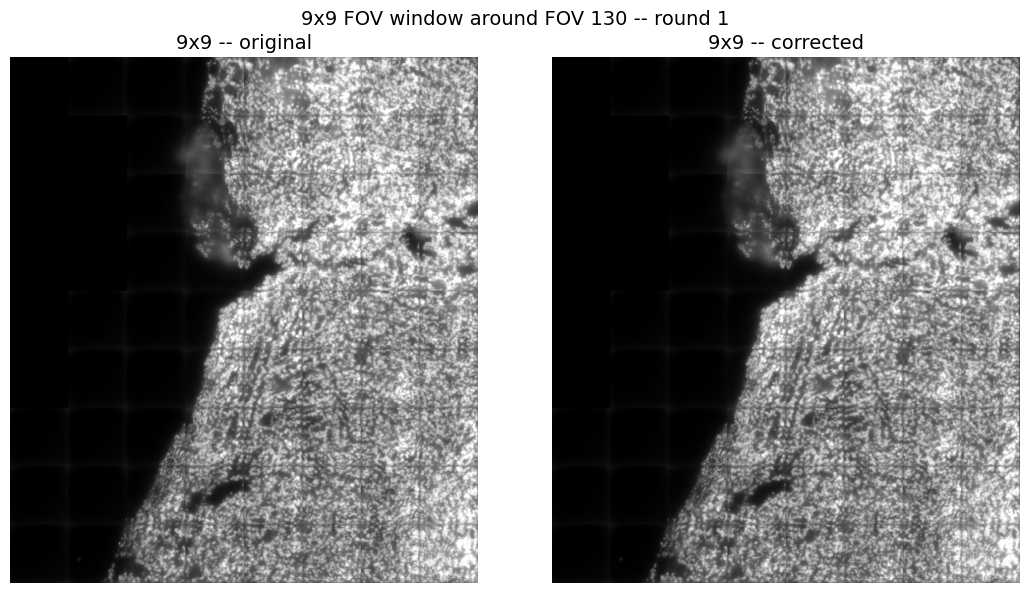

Saved: T:\Leonardo\BC553_sample_02\epi\analysis\figures\correct_camera_rotation.mosaic_9x9.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 6))
for ax, canvas, title in ((axes[0], window_original_canvas, "9x9 -- original"),
                           (axes[1], window_corrected_canvas, "9x9 -- corrected")):
    ax.imshow(canvas, cmap="gray")
    ax.set_title(title, fontsize=PLOT_TITLE_FONTSIZE)
    ax.axis("off")
fig.suptitle(f"9x9 FOV window around FOV {anchor_fov} -- round {target_round_id}",
             fontsize=PLOT_TITLE_FONTSIZE)
fig.tight_layout()
fig_path = figures_dir / f"{NOTEBOOK_NAME}.mosaic_9x9.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")


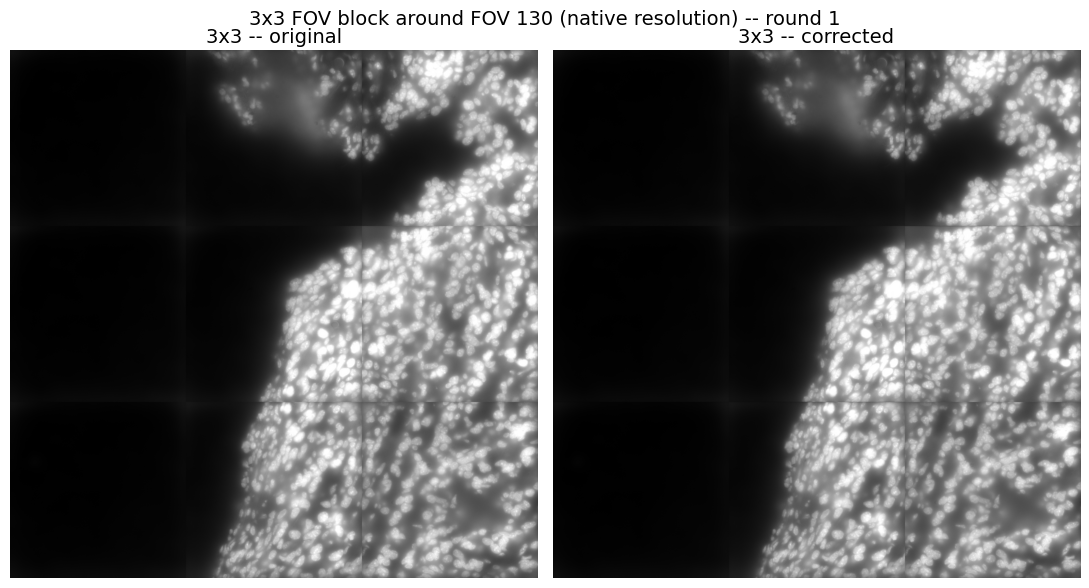

Saved: T:\Leonardo\BC553_sample_02\epi\analysis\figures\correct_camera_rotation.mosaic_3x3.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 6))
for ax, canvas, title in ((axes[0], block3x3_original_canvas, "3x3 -- original"),
                           (axes[1], block3x3_corrected_canvas, "3x3 -- corrected")):
    ax.imshow(canvas, cmap="gray")
    ax.set_title(title, fontsize=PLOT_TITLE_FONTSIZE)
    ax.axis("off")
fig.suptitle(f"3x3 FOV block around FOV {anchor_fov} (native resolution) -- round {target_round_id}",
             fontsize=PLOT_TITLE_FONTSIZE)
fig.tight_layout()
fig_path = figures_dir / f"{NOTEBOOK_NAME}.mosaic_3x3.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")


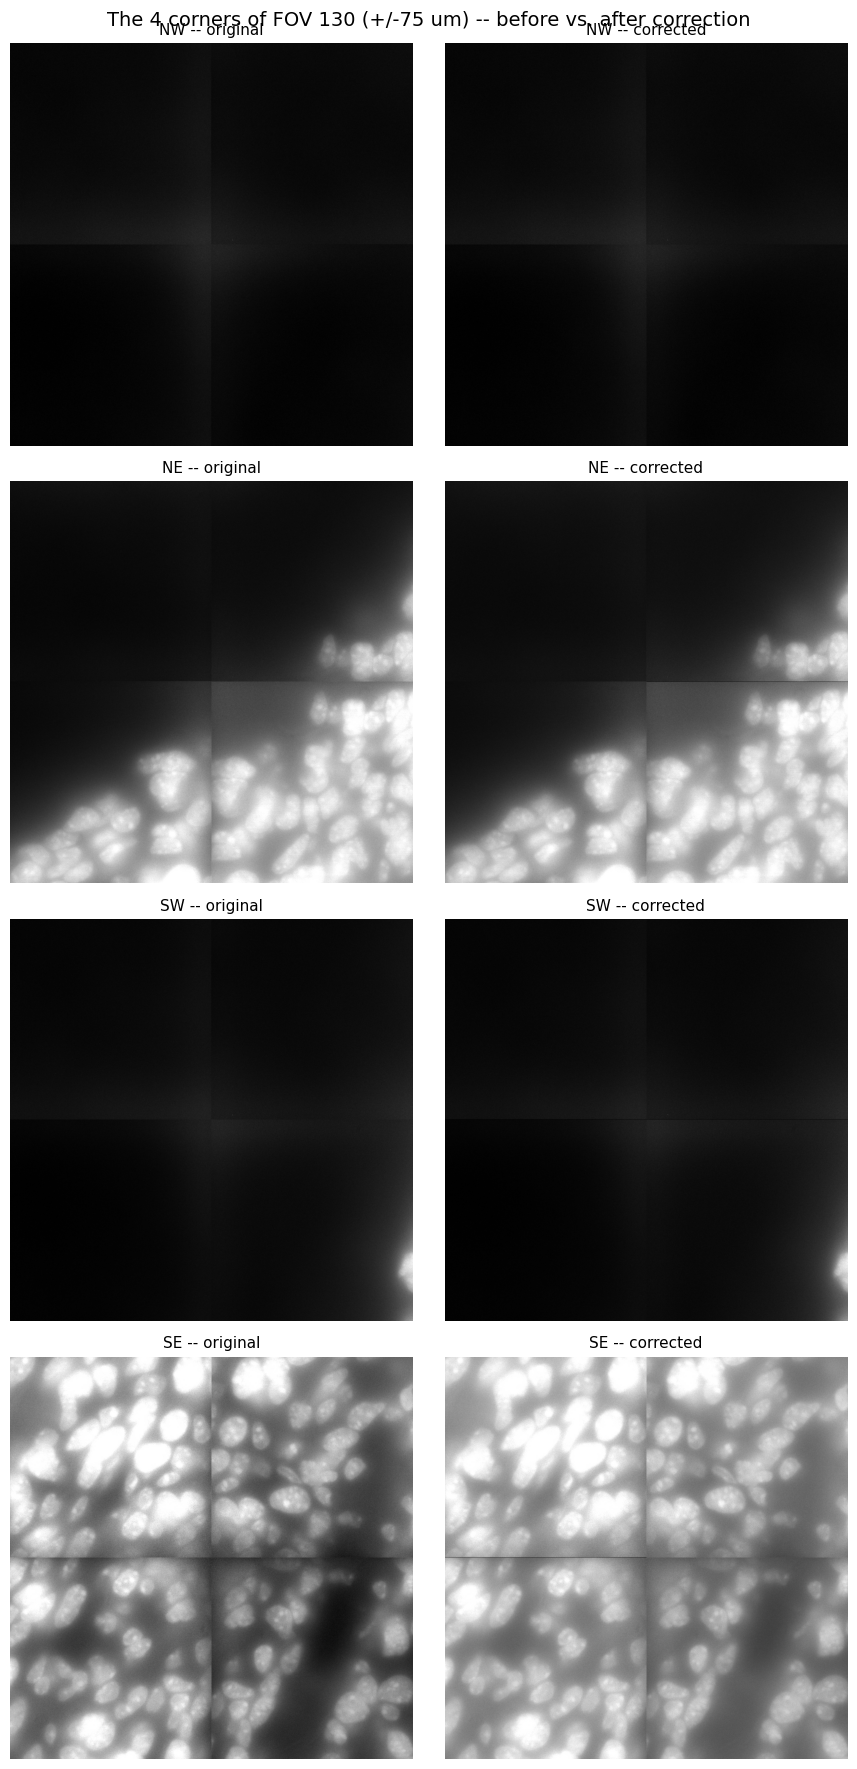

Saved: T:\Leonardo\BC553_sample_02\epi\analysis\figures\correct_camera_rotation.mosaic_4corners.png


In [17]:
fig, axes = plt.subplots(4, 2, figsize=(9, 18))
for row, corner in enumerate(("NW", "NE", "SW", "SE")):
    for col, (corners_dict, title) in enumerate(
        ((block3x3_original_corners, "original"), (block3x3_corrected_corners, "corrected"))
    ):
        ax = axes[row][col]
        ax.imshow(corners_dict[corner], cmap="gray")
        ax.set_title(f"{corner} -- {title}", fontsize=PLOT_TICK_FONTSIZE)
        ax.axis("off")

fig.suptitle(f"The 4 corners of FOV {anchor_fov} (+/-{MOSAIC_2X2_ZOOM_HALF_UM:.0f} um) -- "
             f"before vs. after correction", fontsize=PLOT_TITLE_FONTSIZE)
fig.tight_layout()
fig_path = figures_dir / f"{NOTEBOOK_NAME}.mosaic_4corners.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")


## 12 — Plot: colour overlap overlay of the 2x2 corner block

Same corner block and FFC field as section 11, but placed at each FOV's REAL
position -- so physically overlapping content from adjacent FOVs is drawn ON
TOP of each other, not abutted side by side like section 11's mosaics -- and
each FOV tinted a single colour (red/green/blue/yellow), combined ADDITIVELY
(not by max) so a region covered by more than one FOV shows real colour
mixing (e.g. red+green overlap reads as yellow-orange). Real tissue content
that lines up between FOVs blends into a smooth, single-hued region;
content that doesn't line up shows as separated colour fringing/ghosting of
the same feature.


In [18]:
def build_corner_overlay(frames, positions_um, pixel_size_um, colors, flip_y, ffc_field=None):
    """Place FFC-corrected frames at their real stage positions (nominal or
    corrected), each tinted a distinct colour, combined ADDITIVELY (then
    clipped) so a genuinely overlapping region shows real colour mixing --
    unlike a max-combine, where the brighter tile simply hides the other."""
    from MERci.analysis.ffc import apply_ffc

    h, w = next(iter(frames.values())).shape
    ys_sign = -1.0 if flip_y else 1.0
    xs = [positions_um[n][0] for n in frames]
    ys = [ys_sign * positions_um[n][1] for n in frames]
    x_min = min(xs) - w * pixel_size_um / 2
    y_min = min(ys) - h * pixel_size_um / 2
    x_max = max(xs) + w * pixel_size_um / 2
    y_max = max(ys) + h * pixel_size_um / 2
    canvas_w = int(round((x_max - x_min) / pixel_size_um))
    canvas_h = int(round((y_max - y_min) / pixel_size_um))
    canvas = np.zeros((canvas_h, canvas_w, 3), dtype=np.float32)
    for name, img in frames.items():
        corrected_img = apply_ffc(img, ffc_field) if ffc_field is not None else img.astype(np.float32)
        lo, hi = np.percentile(corrected_img, [1, 99.5])
        norm = np.clip((corrected_img - lo) / max(hi - lo, 1e-6), 0, 1)
        x_um, y_um = positions_um[name][0], ys_sign * positions_um[name][1]
        col0 = int(round((x_um - w * pixel_size_um / 2 - x_min) / pixel_size_um))
        row0 = int(round((y_um - h * pixel_size_um / 2 - y_min) / pixel_size_um))
        tile_rgb = norm[..., None] * np.array(colors[name], dtype=np.float32)
        canvas[row0:row0 + h, col0:col0 + w] += tile_rgb
    return np.clip(canvas, 0, 1)


BLOCK_COLORS = {"anchor": (1.0, 0.0, 0.0), "right": (0.0, 1.0, 0.0),
                "up": (0.0, 0.0, 1.0), "diag": (1.0, 1.0, 0.0)}

overlay_original_positions  = {name: full_positions[fov_id] for name, fov_id in block_names.items()}
overlay_corrected_positions = {name: corrected_positions[fov_id] for name, fov_id in block_names.items()}

overlay_before = build_corner_overlay(block_frames, overlay_original_positions, PIXEL_SIZE_UM,
                                       BLOCK_COLORS, FLIP_Y, ffc_field=ffc_field)
overlay_after  = build_corner_overlay(block_frames, overlay_corrected_positions, PIXEL_SIZE_UM,
                                       BLOCK_COLORS, FLIP_Y, ffc_field=ffc_field)

print(f"Overlay canvases built: before={overlay_before.shape[:2]}, after={overlay_after.shape[:2]}")


Overlay canvases built: before=(3891, 3891), after=(3892, 3891)


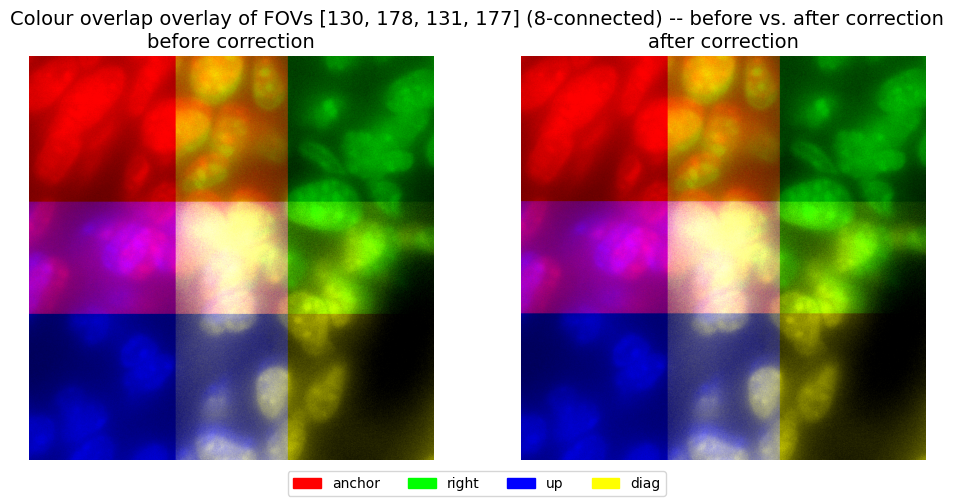

Saved: T:\Leonardo\BC553_sample_02\epi\analysis\figures\correct_camera_rotation.corner_overlay.png


In [19]:
overlay_before_zoom = crop_at(overlay_before, overlay_before.shape[0] // 2, overlay_before.shape[1] // 2,
                               CORNER_ZOOM_HALF_UM, PIXEL_SIZE_UM)
overlay_after_zoom  = crop_at(overlay_after, overlay_after.shape[0] // 2, overlay_after.shape[1] // 2,
                               CORNER_ZOOM_HALF_UM, PIXEL_SIZE_UM)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, crop, title in ((axes[0], overlay_before_zoom, "before correction"),
                         (axes[1], overlay_after_zoom, "after correction")):
    ax.imshow(crop)
    ax.set_title(title, fontsize=PLOT_TITLE_FONTSIZE)
    ax.axis("off")
handles = [mpatches.Patch(color=c, label=n) for n, c in BLOCK_COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=PLOT_LEGEND_FONTSIZE)
fig.suptitle(f"Colour overlap overlay of FOVs {block_fov_ids} (8-connected) -- "
             f"before vs. after correction", fontsize=PLOT_TITLE_FONTSIZE)
fig.tight_layout(rect=[0, 0.05, 1, 1])
fig_path = figures_dir / f"{NOTEBOOK_NAME}.corner_overlay.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")


## 13 -- Plot: 4-direction overlap overlay (centre FOV vs. each cardinal neighbour, before vs. after correction)

Section 12's colour overlay only shows ONE corner (the NE 2x2 block) -- a real
lack of overlap can be much clearer looking at each of the 4 cardinal neighbours
independently, one direction at a time. Reuses `build_corner_overlay` (section 12)
with just 2 tiles (anchor + one neighbour) instead of 4, at both the NOMINAL and
the corrected position.

The centre FOV is chosen automatically among the training anchors that have a kept
(non-outlier) correspondence in ALL 4 cardinal directions, picking whichever one has
the strongest real signal on every side (highest MINIMUM FFT cross-power correlation
peak across its 4 neighbours) -- confirmed directly this matters: an arbitrarily-
picked centre FOV can have little to no real tissue on 1-2 of its sides, in which case
phase correlation there is essentially measuring noise (unstable, wildly different
results under minor preprocessing changes) rather than a real registration, and isn't
a meaningful example of whether the correction is working.


In [20]:
def _overlap_correlation_peak(a_crop, n_crop):
    """FFT cross-power correlation peak (0-1, higher = stronger real match) --
    used only to PICK a well-signalled example FOV for this diagnostic below, not
    as part of the actual registration/fit above (that already happened in
    section 5/6 via phase_drift)."""
    f0 = np.fft.fft2(remove_hot_pixels(a_crop).astype(np.float64))
    f1 = np.fft.fft2(remove_hot_pixels(n_crop).astype(np.float64))
    cross = f0 * np.conj(f1)
    cross /= np.abs(cross) + 1e-10
    return float(np.abs(np.fft.ifft2(cross)).max())


def oriented_frame(fov_id):
    """load_dapi_frame (section 3) is a raw loader -- shared with the fit/audit
    path above, which applies orientation internally -- so this diagnostic must
    apply it explicitly itself, same as block_3x3_frames in section 10."""
    return apply_microscope_orientation(load_dapi_frame(fov_id), ORIENT_TRANSPOSE,
                                         ORIENT_FLIP_HORIZONTAL, ORIENT_FLIP_VERTICAL)


# Candidate centres: training anchors with a KEPT (non-outlier) correspondence in
# all 4 cardinal directions -- pick whichever has real signal on every side.
by_anchor = {}
for c in correspondences:
    by_anchor.setdefault(c.anchor_fov, {})[c.direction] = c.neighbor_fov
complete_anchors = {a: nbs for a, nbs in by_anchor.items()
                    if set(nbs) == {"up", "down", "left", "right"}}
if not complete_anchors:
    raise RuntimeError("No training anchor has all 4 cardinal directions kept -- "
                       "try a larger N_ANCHORS or MAD_THRESHOLD.")

FOUR_DIRECTION_CENTER, best_min_peak, FOUR_DIRECTION_NEIGHBORS = None, -1.0, None
for center_candidate, nbs in complete_anchors.items():
    center_img = oriented_frame(center_candidate)
    peaks = {
        direction: _overlap_correlation_peak(
            *crop_overlap(center_img, oriented_frame(nb_fov), direction, OVERLAP_FRACTION))
        for direction, nb_fov in nbs.items()
    }
    min_peak = min(peaks.values())
    if min_peak > best_min_peak:
        FOUR_DIRECTION_CENTER, best_min_peak, FOUR_DIRECTION_NEIGHBORS = center_candidate, min_peak, nbs

print(f"4-direction overlay centre FOV: {FOUR_DIRECTION_CENTER} (min cross-power peak "
      f"{best_min_peak:.4f} across all 4 neighbours: {FOUR_DIRECTION_NEIGHBORS})")


4-direction overlay centre FOV: 1087 (min cross-power peak 0.0119 across all 4 neighbours: {'right': 1149, 'left': 1082, 'up': 1088, 'down': 1086})


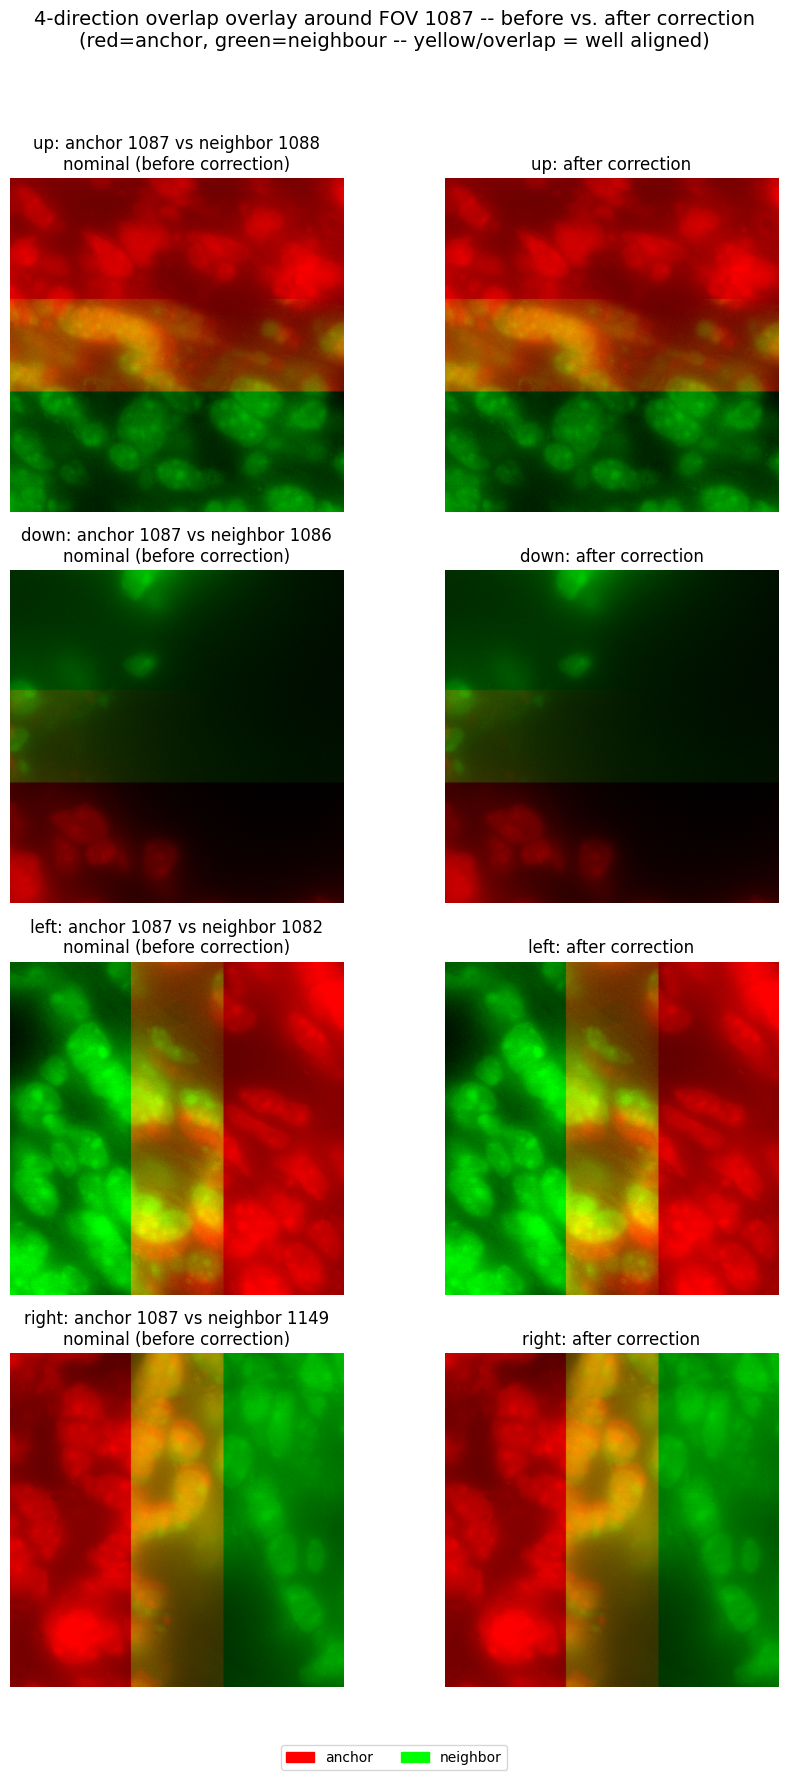

Saved: T:\Leonardo\BC553_sample_02\epi\analysis\figures\correct_camera_rotation.four_direction_overlay.png


In [21]:
FOUR_DIRECTION_COLORS = {"anchor": (1.0, 0.0, 0.0), "neighbor": (0.0, 1.0, 0.0)}

fig, axes = plt.subplots(4, 2, figsize=(9, 18))
for row, direction in enumerate(("up", "down", "left", "right")):
    nb_fov = FOUR_DIRECTION_NEIGHBORS[direction]
    pair_frames = {"anchor": oriented_frame(FOUR_DIRECTION_CENTER), "neighbor": oriented_frame(nb_fov)}

    nominal_pair   = {"anchor": full_positions[FOUR_DIRECTION_CENTER], "neighbor": full_positions[nb_fov]}
    corrected_pair = {"anchor": corrected_positions[FOUR_DIRECTION_CENTER], "neighbor": corrected_positions[nb_fov]}

    overlay_pair_nominal   = build_corner_overlay(pair_frames, nominal_pair, PIXEL_SIZE_UM,
                                                   FOUR_DIRECTION_COLORS, FLIP_Y, ffc_field=ffc_field)
    overlay_pair_corrected = build_corner_overlay(pair_frames, corrected_pair, PIXEL_SIZE_UM,
                                                   FOUR_DIRECTION_COLORS, FLIP_Y, ffc_field=ffc_field)

    # Zoom to the shared edge -- with only 2 tiles positioned at their real stage
    # offset, the bounding canvas's own centre sits right at the shared boundary
    # (same technique as section 12's overlay_before_zoom/overlay_after_zoom).
    zoom_nominal = crop_at(overlay_pair_nominal, overlay_pair_nominal.shape[0] // 2,
                           overlay_pair_nominal.shape[1] // 2, CORNER_ZOOM_HALF_UM, PIXEL_SIZE_UM)
    zoom_corrected = crop_at(overlay_pair_corrected, overlay_pair_corrected.shape[0] // 2,
                             overlay_pair_corrected.shape[1] // 2, CORNER_ZOOM_HALF_UM, PIXEL_SIZE_UM)

    axes[row, 0].imshow(zoom_nominal)
    axes[row, 0].set_title(f"{direction}: anchor {FOUR_DIRECTION_CENTER} vs neighbor {nb_fov}\n"
                           f"nominal (before correction)", fontsize=PLOT_TITLE_FONTSIZE - 2)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(zoom_corrected)
    axes[row, 1].set_title(f"{direction}: after correction", fontsize=PLOT_TITLE_FONTSIZE - 2)
    axes[row, 1].axis("off")

handles = [mpatches.Patch(color=color, label=name) for name, color in FOUR_DIRECTION_COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=PLOT_LEGEND_FONTSIZE)
fig.suptitle(f"4-direction overlap overlay around FOV {FOUR_DIRECTION_CENTER} -- before vs. after correction\n"
             "(red=anchor, green=neighbour -- yellow/overlap = well aligned)", fontsize=PLOT_TITLE_FONTSIZE)
fig.tight_layout(rect=[0, 0.04, 1, 0.95])
fig_path = figures_dir / f"{NOTEBOOK_NAME}.four_direction_overlay.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")


## 14 — Validate the correction on held-out FOVs

A single global affine transform is only a MODEL of the real camera-vs-stage
misalignment. The working assumption is that this model explains ALMOST ALL
of the gap between each FOV's nominal grid position and its real physical
position, leaving only a small, roughly random residual (stage positioning
jitter -- not a systematic rotation/scale/shear a better global affine could
still capture).

To test that assumption instead of just trusting it: sample a FRESH set of
`N_VALIDATION_ANCHORS` anchor FOVs -- disjoint from every anchor used to FIT
the correction in section 6 -- and register them against their own real
neighbours exactly as in section 5. For each held-out correspondence, the
neighbour's independently-*measured* true position (from that registration)
is compared against what the ALREADY-FITTED correction predicts from the
neighbour's nominal position alone -- a genuine out-of-sample check, since
none of these measurements informed the fit.

If the assumption holds: `error_after` should be much smaller than
`error_before`, and what remains should look like unstructured noise with no
obvious spatial pattern (a spatial pattern would mean one global affine is
not actually the right model for this microscope).


In [22]:
VALIDATION_CACHE = CACHE_DIR / "validation_correspondences.csv"

# Disjoint from every anchor already used to fit the correction (section 5/6)
# -- not from every FOV that appears anywhere in a training correspondence,
# since a training NEIGHBOUR and a validation ANCHOR measure different
# (anchor, direction) pairs even when they happen to share a FOV id.
train_anchor_fovs    = set(correspondences_df["anchor_fov"].unique())
validation_candidates = [f for f in fov_order if f not in train_anchor_fovs]

if VALIDATION_CACHE.exists() and not FORCE_RECOMPUTE:
    validation_df = pd.read_csv(VALIDATION_CACHE)
    print(f"Loaded cached validation correspondences: {VALIDATION_CACHE}  ({len(validation_df)} rows)")
else:
    n_validation_actual = min(N_VALIDATION_ANCHORS, len(validation_candidates))
    reporter = ProgressReporter(total=n_validation_actual * 4, label="Registering held-out neighbour pairs")

    def _progress_validation(done, total):
        reporter.update(done - reporter.n_done)

    validation_correspondences = sample_neighbor_correspondences(
        fov_ids=validation_candidates,
        positions=full_positions,
        load_frame=load_dapi_frame,
        step_size_um=STEP_SIZE_UM,
        pixel_size_um=PIXEL_SIZE_UM,
        overlap_fraction=OVERLAP_FRACTION,
        n_anchors=N_VALIDATION_ANCHORS,
        tolerance_fraction=TOLERANCE_FRACTION,
        upsample_factor=UPSAMPLE_FACTOR,
        orient_transpose=ORIENT_TRANSPOSE,
        orient_flip_horizontal=ORIENT_FLIP_HORIZONTAL,
        orient_flip_vertical=ORIENT_FLIP_VERTICAL,
        seed=VALIDATION_SEED,
        progress_callback=_progress_validation,
    )
    reporter.done()

    validation_df = pd.DataFrame([{
        "anchor_fov": c.anchor_fov, "neighbor_fov": c.neighbor_fov, "direction": c.direction,
        "nominal_x": c.nominal_xy[0], "nominal_y": c.nominal_xy[1],
        "measured_x": c.measured_xy[0], "measured_y": c.measured_xy[1],
        "error": c.error,
    } for c in validation_correspondences])
    validation_df.to_csv(VALIDATION_CACHE, index=False)
    print(f"Sampled {len(validation_df)} held-out correspondence(s) from "
          f"{n_validation_actual} validation anchor FOV(s), disjoint from the "
          f"{len(train_anchor_fovs)} training anchor(s). Saved: {VALIDATION_CACHE}")

print(validation_df.head())


Loaded cached validation correspondences: T:\Leonardo\BC553_sample_02\epi\analysis\cache\correct_camera_rotation\validation_correspondences.csv  (38 rows)
   anchor_fov  neighbor_fov direction  nominal_x  nominal_y  measured_x  \
0        1445          1471     right  9475.9336 -5141.9952   9475.9336   
1        1445          1441      left  9077.8024 -5141.9952   9076.4092   
2        1445          1446        up  9276.8680 -4942.9296   9279.8056   
3        1445          1444      down  9276.8680 -5341.0608   9273.7252   
4         307           358     right  2508.6376  -563.4864   2510.0632   

   measured_y  error  
0  -5144.1552    1.0  
1  -5137.6104    1.0  
2  -4942.9296    1.0  
3  -5341.8384    1.0  
4   -567.7740    1.0  


In [23]:
validation_correspondences_all = [
    NeighborCorrespondence(
        anchor_fov=int(r.anchor_fov), neighbor_fov=int(r.neighbor_fov), direction=r.direction,
        nominal_xy=(r.nominal_x, r.nominal_y), measured_xy=(r.measured_x, r.measured_y), error=r.error,
    )
    for r in validation_df.itertuples()
]
validation_kept, validation_rejected = filter_correspondence_outliers(
    validation_correspondences_all, mad_threshold=MAD_THRESHOLD,
)
print(f"Kept {len(validation_kept)}/{len(validation_correspondences_all)} held-out correspondence(s) "
      f"({len(validation_rejected)} rejected as outliers -- same rule as section 6, applied "
      f"independently here since a bad registration is a bad MEASUREMENT of ground truth, "
      f"not a failure of the correction being tested).")
for c in validation_rejected:
    shift_um = float(np.hypot(c.measured_xy[0] - c.nominal_xy[0], c.measured_xy[1] - c.nominal_xy[1]))
    print(f"  rejected: anchor={c.anchor_fov} neighbor={c.neighbor_fov} "
          f"direction={c.direction!r} shift={shift_um:.2f} um")

validation_df = pd.DataFrame([{
    "anchor_fov": c.anchor_fov, "neighbor_fov": c.neighbor_fov, "direction": c.direction,
    "nominal_x": c.nominal_xy[0], "nominal_y": c.nominal_xy[1],
    "measured_x": c.measured_xy[0], "measured_y": c.measured_xy[1],
    "error": c.error,
} for c in validation_kept])

val_nominal   = validation_df[["nominal_x", "nominal_y"]].to_numpy()
val_measured  = validation_df[["measured_x", "measured_y"]].to_numpy()
val_corrected = correction.transform_points(val_nominal)

validation_df["error_before_um"] = np.linalg.norm(val_nominal - val_measured, axis=1)
validation_df["error_after_um"]  = np.linalg.norm(val_corrected - val_measured, axis=1)
validation_df["residual_dx_um"]  = val_corrected[:, 0] - val_measured[:, 0]
validation_df["residual_dy_um"]  = val_corrected[:, 1] - val_measured[:, 1]

median_before = float(validation_df["error_before_um"].median())
median_after  = float(validation_df["error_after_um"].median())

print(f"\nHeld-out position error (n={len(validation_df)} correspondences, "
      f"{validation_df['anchor_fov'].nunique()} FOV(s) not used in the fit):")
print(f"  before correction : median {median_before:.3f} um, "
      f"mean {validation_df['error_before_um'].mean():.3f} um, "
      f"max {validation_df['error_before_um'].max():.3f} um")
print(f"  after correction  : median {median_after:.3f} um, "
      f"mean {validation_df['error_after_um'].mean():.3f} um, "
      f"max {validation_df['error_after_um'].max():.3f} um")
if median_before > 0:
    print(f"  median reduction   : {100 * (1 - median_after / median_before):.1f}%")

if median_after >= median_before:
    print(
        f"\nNOTE: the correction did not reduce held-out position error. This does NOT "
        "necessarily mean the method failed -- it means that, for THIS round/microscope, "
        "the systematic camera-vs-stage rotation is smaller than the random, per-FOV "
        "positioning/registration noise floor (here, a few um). Fitting an affine to noise "
        "cannot improve on it; a real, larger rotation would show a clear reduction instead. "
        f"Check camera_rotation_correction_{POSITIONS_TAG}.json's fitted rotation/scale -- a "
        "value very close to identity (0 deg, scale 1.0) supports this reading."
    )


Kept 35/38 held-out correspondence(s) (3 rejected as outliers -- same rule as section 6, applied independently here since a bad registration is a bad MEASUREMENT of ground truth, not a failure of the correction being tested).
  rejected: anchor=1136 neighbor=1171 direction='right' shift=26.35 um
  rejected: anchor=5 neighbor=26 direction='right' shift=58.61 um
  rejected: anchor=5 neighbor=6 direction='up' shift=100.67 um

Held-out position error (n=35 correspondences, 9 FOV(s) not used in the fit):
  before correction : median 3.391 um, mean 3.493 um, max 7.549 um
  after correction  : median 3.537 um, mean 3.663 um, max 8.491 um
  median reduction   : -4.3%

NOTE: the correction did not reduce held-out position error. This does NOT necessarily mean the method failed -- it means that, for THIS round/microscope, the systematic camera-vs-stage rotation is smaller than the random, per-FOV positioning/registration noise floor (here, a few um). Fitting an affine to noise cannot improve on 

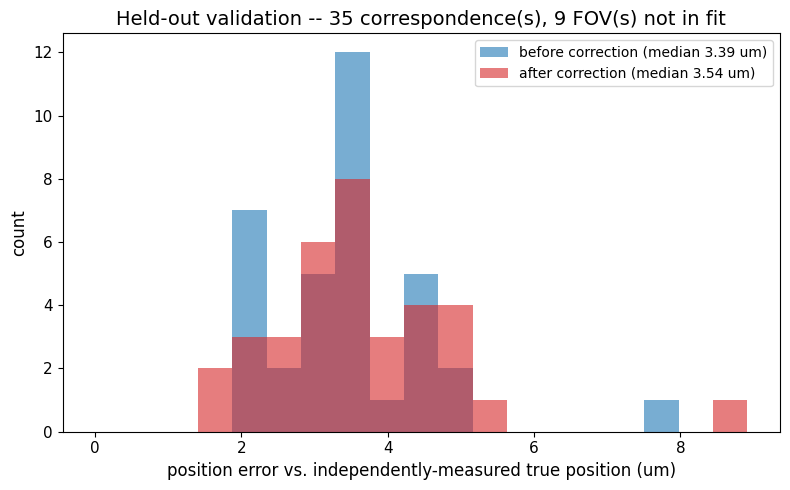

Saved: T:\Leonardo\BC553_sample_02\epi\analysis\figures\correct_camera_rotation.validation_error_histogram.png


In [24]:
error_max = max(validation_df["error_before_um"].max(), validation_df["error_after_um"].max())
bins = np.linspace(0, error_max * 1.05, 20)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(validation_df["error_before_um"], bins=bins, alpha=0.6, color="tab:blue",
        label=f"before correction (median {median_before:.2f} um)")
ax.hist(validation_df["error_after_um"], bins=bins, alpha=0.6, color="tab:red",
        label=f"after correction (median {median_after:.2f} um)")
ax.set_xlabel("position error vs. independently-measured true position (um)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("count", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Held-out validation -- {len(validation_df)} correspondence(s), "
             f"{validation_df['anchor_fov'].nunique()} FOV(s) not in fit",
             fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)
fig.tight_layout()

fig_path = figures_dir / f"{NOTEBOOK_NAME}.validation_error_histogram.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")


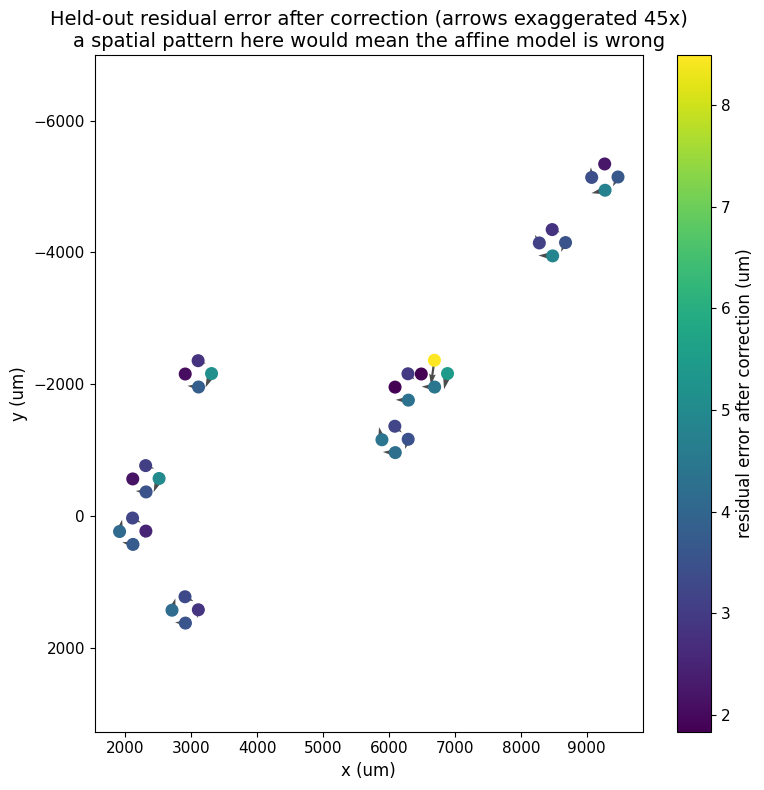

Saved: T:\Leonardo\BC553_sample_02\epi\analysis\figures\correct_camera_rotation.validation_residual_map.png


In [25]:
residual_mag = np.hypot(validation_df["residual_dx_um"], validation_df["residual_dy_um"])
plot_extent  = max(validation_df["measured_x"].max() - validation_df["measured_x"].min(),
                    validation_df["measured_y"].max() - validation_df["measured_y"].min())
arrow_scale  = (0.05 * plot_extent) / max(float(residual_mag.max()), 1e-9)

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(validation_df["measured_x"], validation_df["measured_y"],
                 c=residual_mag, cmap="viridis", s=70, zorder=3)
ax.quiver(validation_df["measured_x"], validation_df["measured_y"],
          validation_df["residual_dx_um"] * arrow_scale, validation_df["residual_dy_um"] * arrow_scale,
          angles="xy", scale_units="xy", scale=1, color="k", width=0.004, alpha=0.7, zorder=2)
ax.invert_yaxis()
ax.axis("equal")
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("residual error after correction (um)", fontsize=PLOT_LABEL_FONTSIZE)
cbar.ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.set_xlabel("x (um)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("y (um)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Held-out residual error after correction (arrows exaggerated {arrow_scale:.0f}x)\n"
             f"a spatial pattern here would mean the affine model is wrong",
             fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
fig.tight_layout()

fig_path = figures_dir / f"{NOTEBOOK_NAME}.validation_residual_map.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")
